In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
nav = pd.read_csv(r"C:\Users\tekam\Downloads\Data Science\Data_Analyst_Portfolio_Project\data\raw\nav_history_clean.csv")

fund = pd.read_csv(r"C:\Users\tekam\Downloads\Data Science\Data_Analyst_Portfolio_Project\data\raw\01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code","date"])

display(nav.head())

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
df = nav.merge(

    fund[["amfi_code","scheme_name"]],

    on="amfi_code",

    how="left"

)

display(df.head())

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [5]:
print(df.columns.tolist())

['amfi_code', 'date', 'nav', 'scheme_name']


In [6]:
# Sort the data

df = df.sort_values(["scheme_name", "date"])

# Calculate Daily Return

df["daily_return"] = (
    df.groupby("scheme_name")["nav"].pct_change()
)

# Remove first row of each scheme (NaN)

df = df.dropna(subset=["daily_return"])

# Check columns

print(df.columns.tolist())

display(df.head())

['amfi_code', 'date', 'nav', 'scheme_name', 'daily_return']


,amfi_code,date,nav,scheme_name,daily_return
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314
3455,101206,2022-01-10,307.5591,ABSL Frontline Equity Fund - Regular - Growth,0.011548


In [7]:
import numpy as np
import pandas as pd

RF = 0.065          # Annual Risk-Free Rate
daily_rf = RF / 252

results = []

for scheme, temp in df.groupby("scheme_name"):

    mean_return = temp["daily_return"].mean()
    std_return = temp["daily_return"].std()

    if std_return > 0:
        sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)
    else:
        sharpe = np.nan

    results.append({
        "Scheme Name": scheme,
        "Average Daily Return": round(mean_return, 6),
        "Daily Std Dev": round(std_return, 6),
        "Sharpe Ratio": round(sharpe, 3) if pd.notna(sharpe) else np.nan
    })

sharpe_df = pd.DataFrame(results)

sharpe_df = sharpe_df.sort_values(
    "Sharpe Ratio",
    ascending=False
).reset_index(drop=True)

display(sharpe_df)

,Scheme Name,Average Daily Return,Daily Std Dev,Sharpe Ratio
0,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.008941,1.448
1,Kotak Flexicap Fund - Regular - Growth,0.001082,0.010008,1.307
2,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.011134,1.235
3,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.008656,1.208
4,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.012152,1.180
5,DSP Midcap Fund - Regular - Growth,0.001055,0.011179,1.132
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.011929,1.094
7,Nippon India Large Cap Fund - Regular - Growth,0.000865,0.008913,1.082
8,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.009177,1.027
9,ICICI Pru Bluechip Fund - Direct - Growth,0.000843,0.009048,1.027


In [8]:
sharpe_df = pd.DataFrame(

    results,

    columns=[

        "Scheme Name",

        "Average Daily Return",

        "Daily Std Dev",

        "Sharpe Ratio"

    ]

)

sharpe_df = sharpe_df.sort_values(

    "Sharpe Ratio",

    ascending=False

)

sharpe_df.reset_index(

    drop=True,

    inplace=True

)

display(sharpe_df)

,Scheme Name,Average Daily Return,Daily Std Dev,Sharpe Ratio
0,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.008941,1.448
1,Kotak Flexicap Fund - Regular - Growth,0.001082,0.010008,1.307
2,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.011134,1.235
3,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.008656,1.208
4,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.012152,1.180
5,DSP Midcap Fund - Regular - Growth,0.001055,0.011179,1.132
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.011929,1.094
7,Nippon India Large Cap Fund - Regular - Growth,0.000865,0.008913,1.082
8,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.009177,1.027
9,ICICI Pru Bluechip Fund - Direct - Growth,0.000843,0.009048,1.027


In [9]:
print("="*60)

print("Top 10 Funds by Sharpe Ratio")

print("="*60)

display(

    sharpe_df.head(10)

)

Top 10 Funds by Sharpe Ratio


,Scheme Name,Average Daily Return,Daily Std Dev,Sharpe Ratio
0,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.008941,1.448
1,Kotak Flexicap Fund - Regular - Growth,0.001082,0.010008,1.307
2,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.011134,1.235
3,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.008656,1.208
4,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.012152,1.180
5,DSP Midcap Fund - Regular - Growth,0.001055,0.011179,1.132
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.011929,1.094
7,Nippon India Large Cap Fund - Regular - Growth,0.000865,0.008913,1.082
8,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.009177,1.027
9,ICICI Pru Bluechip Fund - Direct - Growth,0.000843,0.009048,1.027


In [10]:
import os

os.makedirs(

    "data/processed",

    exist_ok=True

)

sharpe_df.to_csv(

    "C:\\Users\\tekam\\Downloads\\Data Science\\Data_Analyst_Portfolio_Project\\data\\processed\\sharpe_ratio_ranking.csv",

    index=False

)

print("Sharpe Ratio Ranking Saved Successfully")

Sharpe Ratio Ranking Saved Successfully


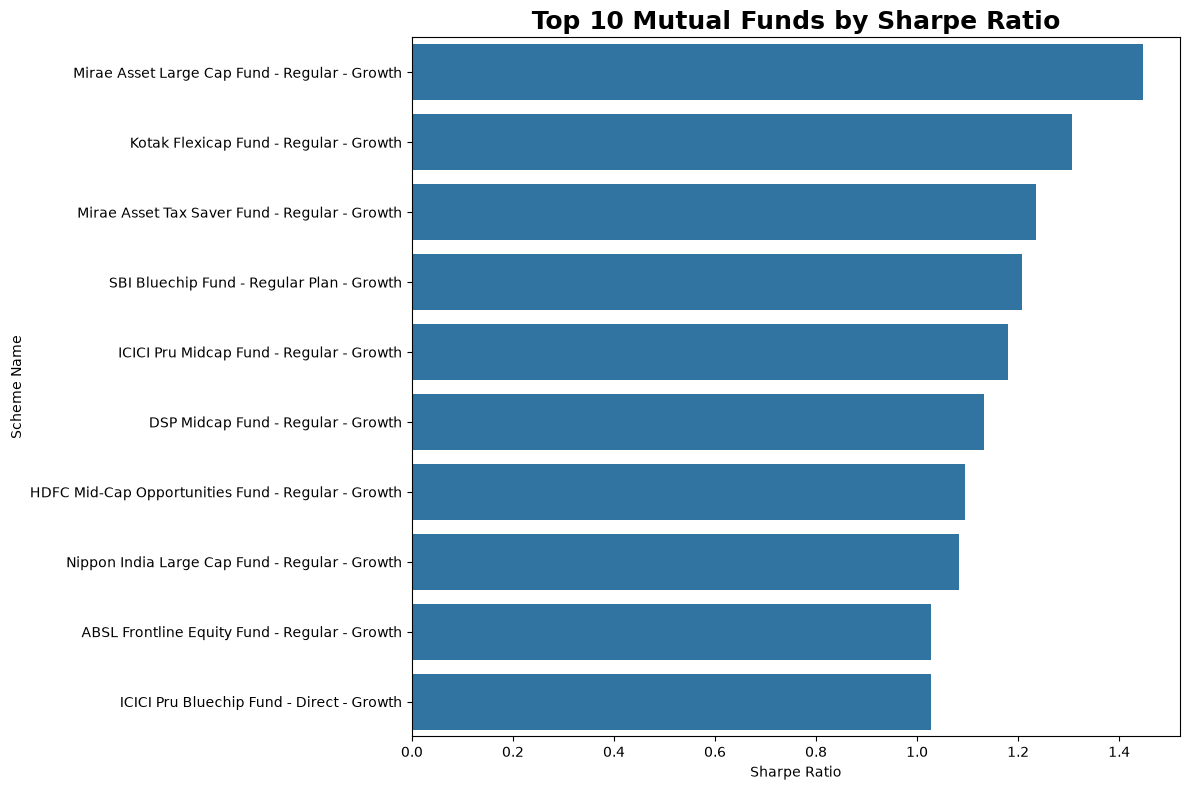

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.barplot(

    data=sharpe_df.head(10),

    y="Scheme Name",

    x="Sharpe Ratio"

)

plt.title(

    "Top 10 Mutual Funds by Sharpe Ratio",

    fontsize=18,

    weight="bold"

)

plt.tight_layout()

plt.show()

## Insight: Sharpe Ratio Ranking

The Sharpe Ratio measures risk-adjusted performance by comparing excess returns over the risk-free rate against return volatility. Funds with higher Sharpe Ratios delivered better returns for each unit of risk and are considered more efficient from a portfolio perspective.

**Chart Reference:** Top 10 Funds by Sharpe Ratio